--- Data Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   train_number             50000 non-null  str    
 1   train_name               49991 non-null  str    
 2   from_station_code        50000 non-null  str    
 3   from_station_name        50000 non-null  str    
 4   to_station_code          50000 non-null  str    
 5   to_station_name          50000 non-null  str    
 6   departure                49864 non-null  str    
 7   arrival                  49864 non-null  str    
 8   duration_h               49864 non-null  float64
 9   duration_m               49864 non-null  float64
 10  distance_km              50000 non-null  float64
 11  classes                  0 non-null      float64
 12  zone                     49864 non-null  str    
 13  hour_of_day              50000 non-null  int64  
 14  day_of_week

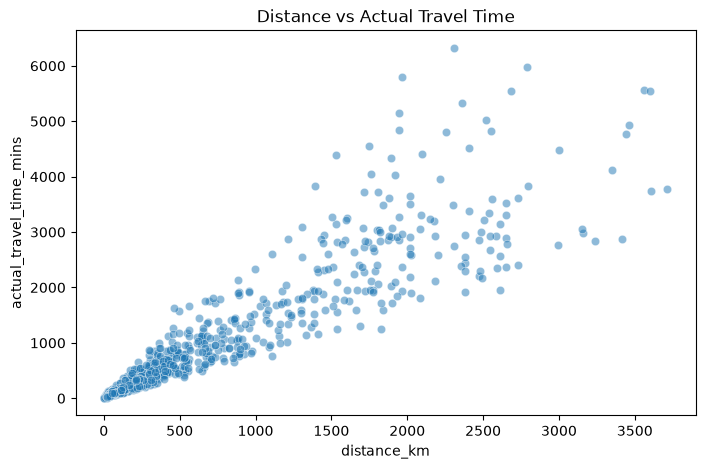

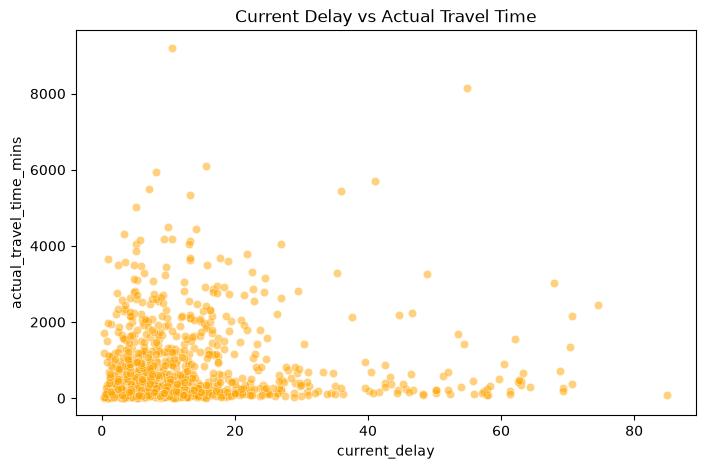

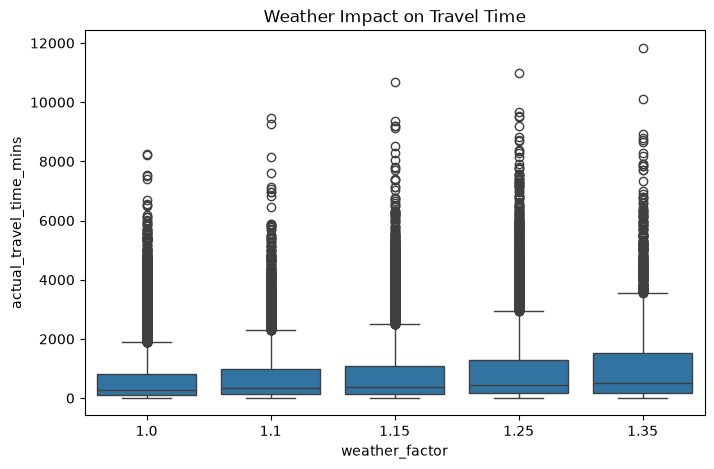

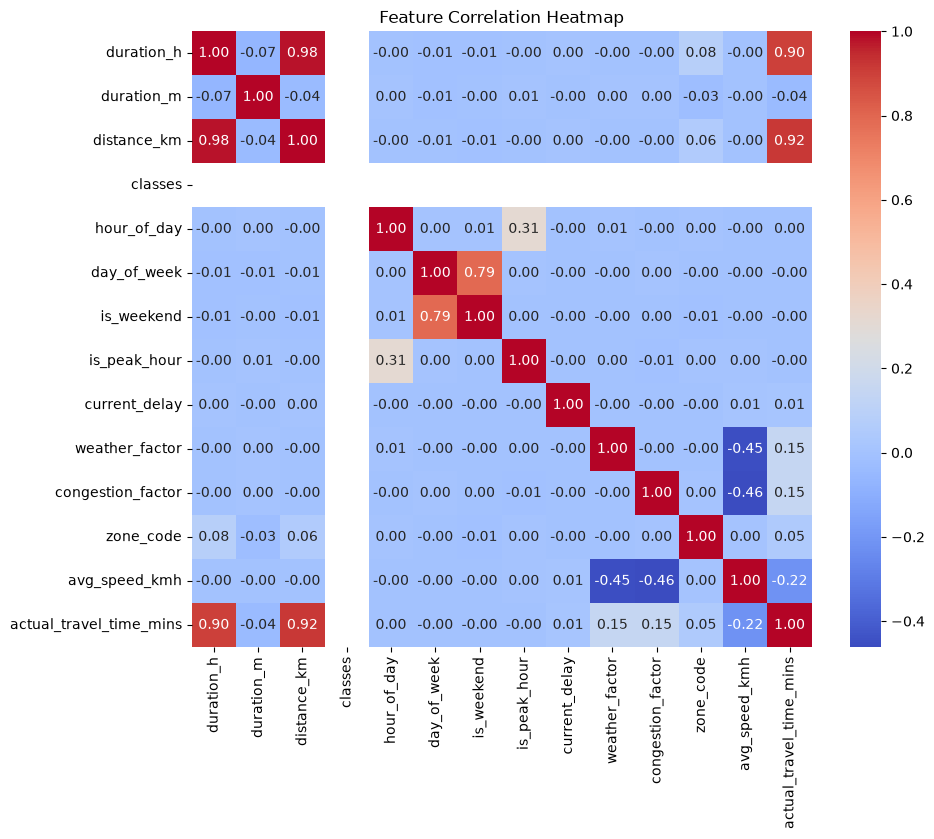

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Data load karo
df = pd.read_csv("train_data_improved.csv")

print("--- Data Overview ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Key Explorations
# Distance vs Travel Time
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(1000),
    x="distance_km",
    y="actual_travel_time_mins",
    alpha=0.5,
)
plt.title("Distance vs Actual Travel Time")
plt.savefig("distance_vs_travel_time.png")
plt.show()

# Current Delay vs Travel Time
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(1000),
    x="current_delay",
    y="actual_travel_time_mins",
    color="orange",
    alpha=0.5,
)
plt.title("Current Delay vs Actual Travel Time")
plt.savefig("delay_vs_travel_time.png")
plt.show()

# Weather Factor Impact
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="weather_factor", y="actual_travel_time_mins")
plt.title("Weather Impact on Travel Time")
plt.savefig("weather_impact.png")
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()